In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_csv("analysis_dataset.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df

,hackathon_name,project_name,project_link,is_winner,inspiration,what_it_does,how_we_built_it,challenges,accomplishments,what_we_learned,what_is_next,tech_stack,external_links,github_links,github_summary
0,Cal Hacks 10.0,Audiogroph,https://devpost.com/software/audiogroph,False,With covid ending and people finding new music...,"The project shows events, creators and any NFT...",We used react to build it in vscode and collab...,We had to learn react and navigate through git...,We have successfully built the frontend of the...,Start planning earlier and commit to branches ...,We need a backend to our project.,"css3, html5, javascript, react",['https://github.com/RyanGertz/CalHacksproject'],['https://github.com/RyanGertz/CalHacksproject'],"The GitHub repository, ""CalHacksproject,"" is a..."
1,Cal Hacks 10.0,Let It Out,https://devpost.com/software/let-it-out-b2xp8u,False,Understanding and expressing emotions can be a...,The user is first prompted to record a vocal b...,Let It Out is a full stack web app. The front ...,The main challenges we ran into came in our fi...,NaN,We learned how to integrate modern technologie...,NaN,"chakra, flask, hume, mongodb, node.js, openai,...","['https://github.com/apolyeti/calhacks10.0,', ...",['https://github.com/apolyeti/calhacks10.0'],"This repository, named `calhacks10.0`, serves ..."
2,Cal Hacks 10.0,Mood Theremin,https://devpost.com/software/mood-theremin,False,"The theremin, an electronic musical instrument...",Mood Theremin translates your facial expressio...,Our project integrates facial expression analy...,NaN,NaN,NaN,NaN,"css, flask, html, hume, javascript, json, pyth...",['https://github.com/Sepulchre49/CalHacks23'],['https://github.com/Sepulchre49/CalHacks23'],The Mood-Theremin repository details a CalHack...
3,Cal Hacks 10.0,Bay Area Safer Housing (B.A.S.H.),https://devpost.com/software/bay-area-safer-ho...,False,The inspiration initially stems from one membe...,B.A.S.H. searches for affordable housing optio...,Our website's foundation was built on next.js ...,Our difficulties lay in our inexperience with ...,"Conceptually, we believe that our project is m...",We've learned most importantly how to better a...,We are serious in our project and are intent o...,"catalog.data.gov, data.sfgov.org, google-maps,...","['https://github.com/matthewaol/b.a.s.h.,']",['https://github.com/matthewaol/b.a.s.h.'],b.a.s.h. (Bay Area Safer Housing) is a CalHack...
4,Cal Hacks 10.0,PawPals,https://devpost.com/software/pawpals-bd8njs,False,"As college students, we both agreed that fun t...","Based on a list of criteria, we prompt OpenAI'...","On the front-end, we utilized Figma to develop...",Some challenges we ran into were the lack of e...,"As a team of two, we were very proud of our fi...",We learned the value of coming up with a plan ...,We hope to deploy the site on Vercel and devel...,"fastapi, figma, openai, python, react.js, sqlite",['https://github.com/Yatsz/PawPals'],['https://github.com/Yatsz/PawPals'],This analysis summarizes the GitHub repository...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6347,HackRice 14 2024,Degree Map AI,https://devpost.com/software/degree-planner-ai,False,As current undergraduate students trying to na...,Degree Map AI includes a React front-end and a...,"We first started by working on the scraper, fr...",One challenge we faced was figuring out the be...,We're proud to have successfully connected the...,"We learned to set up OpenAI's ChatGPT, scrape ...","Given the limited amount of time, we were only...","c++, javascript, openai, pyflask, python, react",['https://github.com/april2546/HackRice2024'],['https://github.com/april2546/HackRice2024'],The HackRice2024-DegreeMapAI project is an inn...
6348,HackRice 14 2024,Money Mania,https://devpost.com/software/money-mania,False,Our inspiration for this project was this book...,This game teaches people about personal financ...,We built this in Python using PyGame. We split...,None of us have ever participa

In [30]:
# Only these text columns should be merged
text_cols = [
    'inspiration', 
    'what_it_does', 
    'how_we_built_it', 
    'challenges', 
    'accomplishments', 
    'what_we_learned',
    'what_is_next',
    'tech_stack'
]

# Combine selected columns into one text column
df['all_text'] = df[text_cols].astype(str).apply(lambda x: ' '.join(x), axis=1)

# Clean up text (remove 'nan', brackets, double spaces)
df['all_text'] = (
    df['all_text']
    .str.replace(r"\bnan\b", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [31]:
df

,hackathon_name,project_name,project_link,is_winner,inspiration,what_it_does,how_we_built_it,challenges,accomplishments,what_we_learned,what_is_next,tech_stack,external_links,github_links,github_summary,all_text
0,Cal Hacks 10.0,Audiogroph,https://devpost.com/software/audiogroph,False,With covid ending and people finding new music...,"The project shows events, creators and any NFT...",We used react to build it in vscode and collab...,We had to learn react and navigate through git...,We have successfully built the frontend of the...,Start planning earlier and commit to branches ...,We need a backend to our project.,"css3, html5, javascript, react",['https://github.com/RyanGertz/CalHacksproject'],['https://github.com/RyanGertz/CalHacksproject'],"The GitHub repository, ""CalHacksproject,"" is a...",With covid ending and people finding new music...
1,Cal Hacks 10.0,Let It Out,https://devpost.com/software/let-it-out-b2xp8u,False,Understanding and expressing emotions can be a...,The user is first prompted to record a vocal b...,Let It Out is a full stack web app. The front ...,The main challenges we ran into came in our fi...,NaN,We learned how to integrate modern technologie...,NaN,"chakra, flask, hume, mongodb, node.js, openai,...","['https://github.com/apolyeti/calhacks10.0,', ...",['https://github.com/apolyeti/calhacks10.0'],"This repository, named `calhacks10.0`, serves ...",Understanding and expressing emotions can be a...
2,Cal Hacks 10.0,Mood Theremin,https://devpost.com/software/mood-theremin,False,"The theremin, an electronic musical instrument...",Mood Theremin translates your facial expressio...,Our project integrates facial expression analy...,NaN,NaN,NaN,NaN,"css, flask, html, hume, javascript, json, pyth...",['https://github.com/Sepulchre49/CalHacks23'],['https://github.com/Sepulchre49/CalHacks23'],The Mood-Theremin repository details a CalHack...,"The theremin, an electronic musical instrument..."
3,Cal Hacks 10.0,Bay Area Safer Housing (B.A.S.H.),https://devpost.com/software/bay-area-safer-ho...,False,The inspiration initially stems from one membe...,B.A.S.H. searches for affordable housing optio...,Our website's foundation was built on next.js ...,Our difficulties lay in our inexperience with ...,"Conceptually, we believe that our project is m...",We've learned most importantly how to better a...,We are serious in our project and are intent o...,"catalog.data.gov, data.sfgov.org, google-maps,...","['https://github.com/matthewaol/b.a.s.h.,']",['https://github.com/matthewaol/b.a.s.h.'],b.a.s.h. (Bay Area Safer Housing) is a CalHack...,The inspiration initially stems from one membe...
4,Cal Hacks 10.0,PawPals,https://devpost.com/software/pawpals-bd8njs,False,"As college students, we both agreed that fun t...","Based on a list of criteria, we prompt OpenAI'...","On the front-end, we utilized Figma to develop...",Some challenges we ran into were the lack of e...,"As a team of two, we were very proud of our fi...",We learned the value of coming up with a plan ...,We hope to deploy the site on Vercel and devel...,"fastapi, figma, openai, python, react.js, sqlite",['https://github.com/Yatsz/PawPals'],['https://github.com/Yatsz/PawPals'],This analysis summarizes the GitHub repository...,"As college students, we both agreed that fun t..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6347,HackRice 14 2024,Degree Map AI,https://devpost.com/software/degree-planner-ai,False,As current undergraduate students trying to na...,Degree Map AI includes a React front-end and a...,"We first started by working on the scraper, fr...",One challenge we faced was figuring out the be...,We're proud to have successfully connected the...,"We learned to set up OpenAI's ChatGPT, scrape ...","Given the limited amount of time, we were only...","c++, javascript, openai, pyflask, python, react",['https://github.com/april2546/HackRice2024'],['https://github.com/april2546/HackRice2024'],The HackRice2024-DegreeMapAI project is an i

In [32]:
df_ml = df[['is_winner', 'github_summary', 'all_text']]
df_ml

,is_winner,github_summary,all_text
0,False,"The GitHub repository, ""CalHacksproject,"" is a...",With covid ending and people finding new music...
1,False,"This repository, named `calhacks10.0`, serves ...",Understanding and expressing emotions can be a...
2,False,The Mood-Theremin repository details a CalHack...,"The theremin, an electronic musical instrument..."
3,False,b.a.s.h. (Bay Area Safer Housing) is a CalHack...,The inspiration initially stems from one membe...
4,False,This analysis summarizes the GitHub repository...,"As college students, we both agreed that fun t..."
...,...,...,...
6347,False,The HackRice2024-DegreeMapAI project is an inn...,As current undergraduate students trying to na...
6348,False,"The Hackathon24 project is a ""Personal Finance...",Our inspiration for this project was this book...
6349,False,"The GitHub repository ""Ai_Audio_Analysis"" is d...",The inspiration behind this project came from ...
6350,False,"The GitHub repository ""HackRice14_RecoveryIO,""...",RestoreIO was created in response to the deman...


In [33]:
df_ml.is_winner.value_counts()

is_winner
False    5246
True     1106
Name: count, dtype: int64

In [34]:
df.hackathon_name.value_counts()

hackathon_name
TreeHacks 2024           404
Hack The North 2020      386
TreeHacks 2023           346
VTHacks 12 2024          278
Hack The North 2021      278
ShellHacks 2024          264
HackHarvard 2024         253
LAHacks 2024             248
TAMUhack X 2024          208
HackGT X                 198
Hack The North 2023      168
Cal Hacks 10.0           158
TreeHacks 2025           154
Hack The North 2022      140
PennApps XXV 2024        138
Hack the Valley 8        132
HackIllinois 2024        132
ShellHacks 2020          129
ShellHacks 2023          122
TreeHacks 2021           120
VTHacks 12               119
HackGT 7                 108
HackGT 9                 105
HackIllinois 2023        104
LA Hacks 2020             99
Cal Hacks 9.0             97
Hack&Roll 2021            91
TreeHacks 2020            91
HackMIT 2023              83
HackRice 14 2024          80
Cal Hacks 8.0             77
HackNJIT 2024             74
TAMUhack 2021             72
HackHarvard 2022          64

In [35]:
#Machine learning starts

In [36]:
# Drop rows with missing values (optional)
df_ml = df_ml.dropna(subset=['github_summary', 'all_text'])
df_ml['text'] = df_ml['github_summary'] + ' ' + df_ml['all_text']
df_ml['label'] = df_ml['is_winner'].astype(int)

In [37]:
# Sample 1000 True and 1000 False examples randomly
df_true = df_ml[df_ml['is_winner'] == True].sample(n=1000, random_state=42)
df_false = df_ml[df_ml['is_winner'] == False].sample(n=1000, random_state=42)
df_balanced = pd.concat([df_true, df_false]).sample(frac=1, random_state=42).reset_index(drop=True)
df_balanced['is_winner'].value_counts()

is_winner
False    1000
True     1000
Name: count, dtype: int64

In [38]:
X = df_balanced['text']
X

0       The GitHub repository, `repo-sit`, hosts a cro...
1       This analysis provides a comprehensive overvie...
2       The GitHub repository, named GTX, presents as ...
3       This repository, named MedChain_HackPSU, detai...
4       The `wanderlust-htn` repository hosts Wanderlu...
                              ...                        
1995    The `luminder` repository contains a dating ap...
1996    The GitHub repository "QuickTeam" presents its...
1997    The `3dReal` GitHub repository appears to be a...
1998    This analysis provides a comprehensive overvie...
1999    The Genie-Tutor project is an innovative Pytho...
Name: text, Length: 2000, dtype: object

In [39]:
y = df_balanced['label']
y

0       0
1       1
2       0
3       1
4       0
       ..
1995    0
1996    0
1997    1
1998    0
1999    0
Name: label, Length: 2000, dtype: int32

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=200)

Accuracy: 0.6925

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.69      0.69       200
           1       0.69      0.69      0.69       200

    accuracy                           0.69       400
   macro avg       0.69      0.69      0.69       400
weighted avg       0.69      0.69      0.69       400



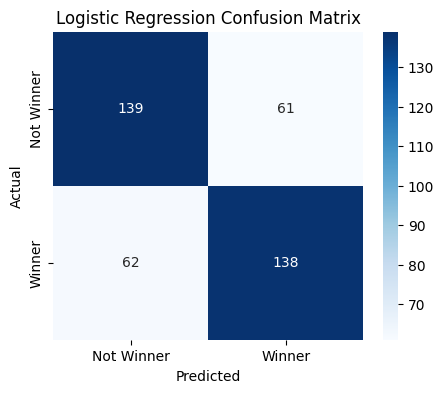

In [43]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Winner", "Winner"], yticklabels=["Not Winner", "Winner"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [44]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC


🌲 Random Forest Results
Accuracy: 0.7375
              precision    recall  f1-score   support

           0       0.71      0.81      0.76       200
           1       0.78      0.66      0.72       200

    accuracy                           0.74       400
   macro avg       0.74      0.74      0.74       400
weighted avg       0.74      0.74      0.74       400



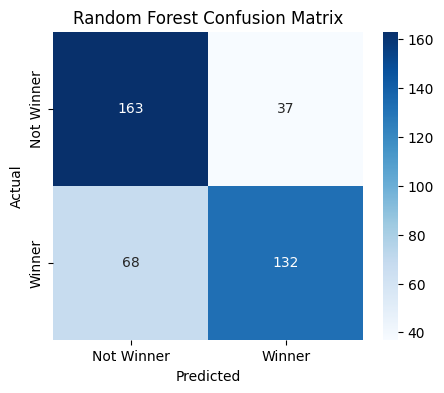

In [45]:
# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_tfidf, y_train)
rf_pred = rf.predict(X_test_tfidf)
print("🌲 Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Winner", "Winner"], yticklabels=["Not Winner", "Winner"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest Confusion Matrix')
plt.show()


🚀 XGBoost Results
Accuracy: 0.71
              precision    recall  f1-score   support

           0       0.70      0.73      0.72       200
           1       0.72      0.69      0.70       200

    accuracy                           0.71       400
   macro avg       0.71      0.71      0.71       400
weighted avg       0.71      0.71      0.71       400



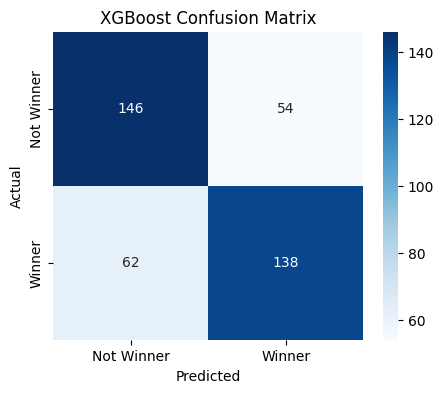

In [46]:
# --- XGBoost ---
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_tfidf, y_train)
xgb_pred = xgb.predict(X_test_tfidf)
print("\n🚀 XGBoost Results")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Winner", "Winner"], yticklabels=["Not Winner", "Winner"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('XGBoost Confusion Matrix')
plt.show()

C:\Users\gauur\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(



⚡ Linear SVC Results
Accuracy: 0.7025
              precision    recall  f1-score   support

           0       0.71      0.69      0.70       200
           1       0.70      0.72      0.71       200

    accuracy                           0.70       400
   macro avg       0.70      0.70      0.70       400
weighted avg       0.70      0.70      0.70       400



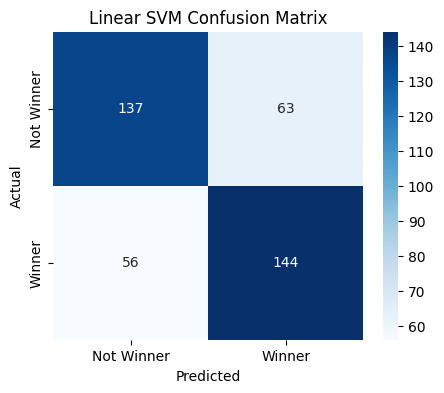

In [47]:
# --- Linear SVM ---
svm = LinearSVC(random_state=42)
svm.fit(X_train_tfidf, y_train)
svm_pred = svm.predict(X_test_tfidf)
print("\n⚡ Linear SVC Results")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))


cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Winner", "Winner"], yticklabels=["Not Winner", "Winner"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Linear SVM Confusion Matrix')
plt.show()


⚡ SVM (RBF kernel) Results
Accuracy: 0.745
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       200
           1       0.75      0.73      0.74       200

    accuracy                           0.74       400
   macro avg       0.75      0.74      0.74       400
weighted avg       0.75      0.74      0.74       400



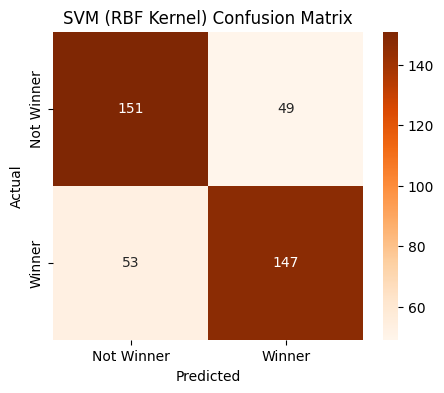

In [48]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- SVM with RBF kernel ---
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train_tfidf, y_train)
svm_rbf_pred = svm_rbf.predict(X_test_tfidf)

print("\n⚡ SVM (RBF kernel) Results")
print("Accuracy:", accuracy_score(y_test, svm_rbf_pred))
print(classification_report(y_test, svm_rbf_pred))

cm = confusion_matrix(y_test, svm_rbf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=["Not Winner", "Winner"], 
            yticklabels=["Not Winner", "Winner"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('SVM (RBF Kernel) Confusion Matrix')
plt.show()


In [49]:
# --- Base models ---
estimators = [
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )),
    ('lr_base', LogisticRegression(
        max_iter=200,
        solver='lbfgs',
        random_state=42
    ))
]

In [50]:
# --- Meta-model (final classifier) ---
meta_model = LogisticRegression(max_iter=300, random_state=42)

Stacking Model Results
Accuracy: 0.7075
              precision    recall  f1-score   support

           0       0.70      0.73      0.72       200
           1       0.72      0.68      0.70       200

    accuracy                           0.71       400
   macro avg       0.71      0.71      0.71       400
weighted avg       0.71      0.71      0.71       400



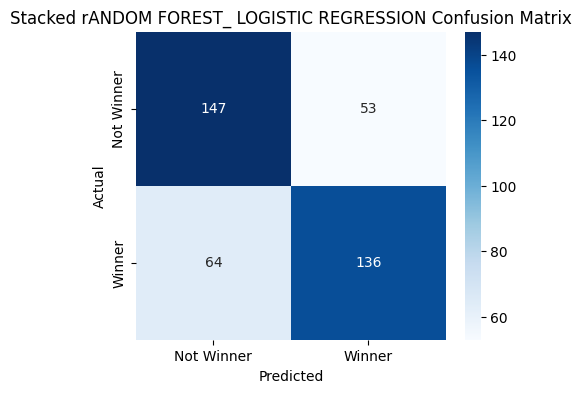

In [51]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier

# --- Stacking ensemble ---
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    stack_method='auto',
    n_jobs=-1,
    passthrough=False
)

# --- Train ---
stack_model.fit(X_train_tfidf, y_train)

# --- Evaluate ---
y_pred = stack_model.predict(X_test_tfidf)

print("Stacking Model Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Winner", "Winner"], yticklabels=["Not Winner", "Winner"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Stacked rANDOM FOREST_ LOGISTIC REGRESSION Confusion Matrix')
plt.show()

In [52]:
#STACK ALL